# Tramo lineal de la rampa: tres formas de encontrarlo y qué tan bien cierran la ida y la vuelta

**Qué se quiere mostrar.** La platina barre un triángulo: sube (ida) y baja (vuelta).
Sólo una parte de cada pasada es una rampa a velocidad constante; el resto es
aceleración, frenado y las puntas. Esa parte lineal es la única en la que un scan
sirve para medir. La pregunta de este cuaderno es:

1. **¿Dónde empieza y dónde termina la parte lineal?** Se responde de tres maneras
   independientes (celdas 2, 3 y 4). Que las tres coincidan es la prueba de que el
   tramo es real y no lo está poniendo el umbral que elegimos.
2. **¿La ida y la vuelta barren el mismo tramo de espacio?** No: el lazo se atrasa
   una cantidad fija `v·tau`, y como en la vuelta la velocidad cambia de signo, los
   dos tramos quedan corridos `2·v·tau` entre sí. Ese **desfasaje** es lo que se
   pierde si se quiere usar las dos pasadas sobre la misma grilla. Se mide entre los
   dos puntos que corresponden a la **misma posición comandada** (el centro del
   solapamiento), no entre las puntas de cada tramo: las puntas dependen del criterio,
   el desfasaje no.
3. **¿Qué WTR y qué SUD conviene usar?** (celdas 5 y 6). WTR fija la velocidad;
   SUD, cuántos puntos se gastan acelerando en cada punta.

**Cómo leer cada una de las celdas 2, 3 y 4.** Todas terminan en la misma figura de
tres paneles y el mismo bloque de números, para que se puedan comparar directamente:

| panel | qué muestra |
|---|---|
| (a) | la rampa entera, con el tramo lineal de la ida en azul y el de la vuelta en rojo |
| (b) | la señal sobre la que se aplicó el criterio, con sus umbrales y los tiempos de corte |
| (c) | los mismos dos tramos sobre el **eje de posición**: ahí se ve el solapamiento y el desfasaje |

y los números que se reportan siempre son: **tiempo perdido antes del tramo lineal**,
**puntos utilizables**, **solapamiento ida ∩ vuelta**, **desfasaje** y **cuánto de cada
tramo se pierde porque no encaja con la otra pasada**.

> Ejecutar las celdas en orden. En Google Colab la celda 0 clona el repositorio con
> los datos; en local encuentra la carpeta sola.


## Celda 0 — lo necesario

Imports, acceso a los datos y las funciones que se usan en todas las celdas:
`cargar` (una corrida), `derivar` (velocidad, promediando sobre un peldaño de la
escalera), `mesetas_en_patas` (el criterio de meseta, común a las celdas 2 y 3),
`resumen` (los números que se reportan siempre) y `figura` (los tres paneles).

Están todas acá y no repetidas en cada celda justamente para que las celdas 2, 3 y 4
se diferencien **sólo** en el criterio, que es lo que se quiere comparar.


In [1]:
# =============================================================================
#  CELDA 0 - lo necesario: acceso a los datos y las funciones que se repiten
# =============================================================================
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def buscar_repo():
    """Carpeta del repositorio. En Colab lo clona; en local lo busca hacia arriba."""
    for d in (Path.cwd(), *Path.cwd().parents):
        if (d / "datos/raw").is_dir():
            return d
    destino = Path.cwd() / "laboratorio-7"
    if not (destino / "datos/raw").is_dir():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/franaguirreram/laboratorio-7.git",
                        str(destino)], check=True)
    return destino


REPO = buscar_repo()
RAW, META = REPO / "datos/raw", REPO / "datos/metadata"

T_SERVO_US = 39.999984          # [MEDIDO] periodo del lazo de servo del E-517

plt.rcParams.update({"font.family": "serif", "font.size": 9, "figure.dpi": 120,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5})
COL = {"ida": "#1f77b4", "vuelta": "#d62728", "comun": "#2ca02c",
       "cmd": "0.75", "med": "0.25"}


# --------------------------------------------------------------- lectura ---
def leer_meta(stem):
    """Metadata de una corrida, como diccionario de strings."""
    lineas = (META / f"{stem}_metadata.txt").read_text().splitlines()
    return dict(l.split("=", 1) for l in lineas if "=" in l and not l.startswith("#"))


def separar_patas(x_cmd):
    """Indices de arranque, pico y fin del triangulo, leidos del COMANDO."""
    excursion = x_cmd.max() - x_cmd.min()
    arranque = int(np.argmax(np.abs(x_cmd - x_cmd[0]) > excursion / 1000))
    pico = int(np.argmax(x_cmd))
    fin = int(np.argmin(np.abs(x_cmd[pico:] - x_cmd[arranque]))) + pico
    return arranque, pico, fin


def cargar(stem):
    """Una corrida completa, con todo lo que despues se usa en todas las celdas."""
    m = leer_meta(stem)
    df = pd.read_csv(RAW / f"{stem}.csv")
    rtr, wtr = int(m["rtr"]), int(m["wtr"])
    x_cmd = df["target_um"].to_numpy()
    x_med = df["current_um"].to_numpy()
    arranque, pico, fin = separar_patas(x_cmd)

    r = {"stem": stem,
         "t_ms": np.arange(len(df)) * rtr * T_SERVO_US / 1e3,
         "x_cmd": x_cmd,
         "x_med": x_med,
         # el error que devuelve el CONTROLADOR, no uno recalculado por nosotros
         "err_nm": df["error_um"].to_numpy() * 1e3,
         "dt_ms": rtr * T_SERVO_US / 1e3,
         "wtr": wtr, "rtr": rtr, "sud": int(m["speedupdown"]),
         "n_total": int(m["n_total"]), "amplitud_um": float(m["amplitud_um"]),
         "arranque": arranque, "pico": pico, "fin": fin,
         "muestras_por_punto": max(wtr // rtr, 1),
         "dwell_us": wtr * T_SERVO_US}

    # dx se MIDE en el medio de la ida: con sud > 0 el generador reparte los
    # puntos de forma no uniforme y 2A/n_total ya no vale.
    a, b = arranque, pico
    centro = x_cmd[a + (b - a) // 3: a + 2 * (b - a) // 3]
    paso = centro[::r["muestras_por_punto"]]
    r["dx_nm"] = float(np.median(np.abs(np.diff(paso))) * 1e3) if len(paso) > 2 else np.nan
    r["v_um_s"] = r["dx_nm"] / r["dwell_us"] * 1e3          # nm/us -> um/s
    return r


# ------------------------------------------------------------ herramientas --
def suavizar(y, n):
    """Media movil de n muestras, extendiendo los bordes (no rellena con ceros)."""
    n = max(int(n), 1)
    if n <= 1:
        return np.asarray(y, float)
    pad = n // 2
    yp = np.pad(np.asarray(y, float), pad, mode="edge")
    return np.convolve(yp, np.ones(n) / n, mode="same")[pad:pad + len(y)]


def derivar(t_ms, x, n):
    """Velocidad en um/s. Suaviza antes y despues: el comando es una ESCALERA.

    El generador cambia el setpoint una vez cada WTR ciclos de servo y se queda
    quieto en el medio, asi que derivar punto a punto da cero la mayor parte del
    tiempo. Hay que promediar sobre al menos un peldano entero.
    """
    v = np.gradient(suavizar(x, 2 * n), np.asarray(t_ms) * 1e-3)
    return suavizar(v, n)


def tramo_mas_largo(mascara):
    """Indices del tramo contiguo mas largo de una mascara booleana."""
    idx = np.where(mascara)[0]
    if len(idx) == 0:
        return idx
    return max(np.split(idx, np.where(np.diff(idx) > 1)[0] + 1), key=len)


def mesetas_en_patas(r, senal, frac):
    """El criterio comun a las celdas 2 y 3, en una sola funcion.

    Se normaliza la senal entre su minimo y su maximo dentro de la onda (por
    percentiles 1 y 99, para que un pico aislado no fije la escala) y se pide
    que supere `frac` en la ida y que quede por debajo de 1-frac en la vuelta.
    De cada mascara se toma el tramo contiguo mas largo.
    """
    reg = slice(r["arranque"], r["fin"])
    lo, hi = np.percentile(senal[reg], 1), np.percentile(senal[reg], 99)
    u_ida, u_vuelta = lo + frac * (hi - lo), lo + (1 - frac) * (hi - lo)

    n = len(senal)
    dentro = lambda a, b: (np.arange(n) >= a) & (np.arange(n) <= b)
    seg = {"ida": tramo_mas_largo((senal >= u_ida) & dentro(r["arranque"], r["pico"])),
           "vuelta": tramo_mas_largo((senal <= u_vuelta) & dentro(r["pico"] + 1, r["fin"]))}
    return seg, (u_ida, u_vuelta)


def zona_quieta(r):
    """Muestras con la platina parada: el ultimo cuarto de la grabacion.

    La ventana grabada es mas larga que la onda, asi que despues del ultimo punto
    de la wave quedan decenas de ms con la platina quieta en el punto de partida.
    Es mucho mejor sitio para medir ruido que los pocos ms de antes del arranque.
    """
    n = len(r["t_ms"])
    return np.arange(n - n // 4, n)


def ruido(r):
    """El ruido de sensado, medido con la platina parada.

    - rms        : dispersion de la posicion medida (incluye la deriva lenta)
    - sigma      : ruido punto a punto, de la diferencia entre muestras
                   consecutivas: var(x[n]-x[n-1]) = 2*sigma^2
    - mediana_dif: la mediana de |diferencias|. Es la estimacion robusta que se
                   usa en la celda 4, pero OJO: el recorder entrega la posicion
                   con 0.1 nm de resolucion, asi que con la platina quieta esta
                   mediana suele dar 0 o 0.1 nm y satura. Por eso la celda 4 se
                   queda con la mayor de las dos estimaciones.
    """
    z = zona_quieta(r)
    d = np.diff(r["x_med"][z])
    return {"n": len(z), "ms": len(z) * r["dt_ms"],
            "rms_nm": float(np.std(r["x_med"][z]) * 1e3),
            "sigma_nm": float(np.std(d) / np.sqrt(2) * 1e3),
            "mediana_dif_nm": float(np.median(np.abs(d)) * 1e3),
            "resolucion_nm": 0.1}


# ------------------------------------------------- reporte comun y figura ---
def resumen(r, seg, metodo="", imprimir=True):
    """Los numeros que se piden para los tres metodos, siempre los mismos.

    tiempo perdido antes del tramo lineal, puntos utilizables, solapamiento de
    los rangos de la ida y de la vuelta, y el desfasaje entre las dos pasadas.
    """
    t, xm, xc = r["t_ms"], r["x_med"], r["x_cmd"]
    arranca = {"ida": r["arranque"], "vuelta": r["pico"]}
    info = {}
    for cual in ("ida", "vuelta"):
        i = np.asarray(seg.get(cual, []), int)
        if len(i) < 3:
            continue
        x0, x1 = xm[i[0]], xm[i[-1]]
        info[cual] = {
            "i": i,
            "t0": t[i[0]], "t1": t[i[-1]], "dur_ms": t[i[-1]] - t[i[0]],
            "t_antes_ms": t[i[0]] - t[arranca[cual]],
            "n_muestras": len(i),
            "n_puntos": len(i) / r["muestras_por_punto"],
            "lo": min(x0, x1), "hi": max(x0, x1),
            "largo_nm": abs(x1 - x0) * 1e3,
            "v_um_s": float(np.polyfit(t[i] * 1e-3, xm[i], 1)[0]),
            "lag_nm": float(np.median(xm[i] - xc[i])) * 1e3}

    res = {"metodo": metodo, "stem": r["stem"], "tramos": info}
    if len(info) == 2:
        lo = max(info["ida"]["lo"], info["vuelta"]["lo"])
        hi = min(info["ida"]["hi"], info["vuelta"]["hi"])
        res["comun_lo"], res["comun_hi"] = lo, hi
        res["solapamiento_nm"] = max(hi - lo, 0.0) * 1e3
        # EL DESFASAJE. Hay que medirlo entre los dos puntos que corresponden a
        # la MISMA posicion comandada, no entre las puntas de los tramos (que
        # empiezan y terminan donde cada criterio los corta). Se toma como
        # referencia el centro del solapamiento: se busca en cada pasada el
        # instante en que el comando pasa por ahi y se comparan las posiciones
        # medidas. Esa distancia es el 2*v*tau.
        x_ref = (lo + hi) / 2
        marca = {}
        for cual, d in info.items():
            j = d["i"][int(np.argmin(np.abs(xc[d["i"]] - x_ref)))]
            marca[cual] = float(xm[j])
        res["x_ref"], res["marca"] = x_ref, marca
        res["desfasaje_nm"] = (marca["vuelta"] - marca["ida"]) * 1e3
        res["desfasaje_por_lag_nm"] = info["vuelta"]["lag_nm"] - info["ida"]["lag_nm"]
        res["corrimiento_bordes_nm"] = ((info["vuelta"]["lo"] - info["ida"]["lo"])
                                        + (info["vuelta"]["hi"] - info["ida"]["hi"])) / 2 * 1e3
        res["puntos_totales"] = sum(d["n_puntos"] for d in info.values())
        res["puntos_comunes"] = res["solapamiento_nm"] / r["dx_nm"]
        res["t_inversion_ms"] = info["vuelta"]["t0"] - info["ida"]["t1"]
        for cual, d in info.items():
            d["perdido_nm"] = d["largo_nm"] - res["solapamiento_nm"]
            d["perdido_frac"] = d["perdido_nm"] / d["largo_nm"] if d["largo_nm"] else np.nan

    if imprimir:
        print(f"┌─ {metodo}   ·   {r['stem']}")
        for cual, d in info.items():
            print(f"│ {cual:>6}  t = {d['t0']:7.2f} .. {d['t1']:7.2f} ms "
                  f"({d['dur_ms']:6.2f} ms)   v = {d['v_um_s']:+9.3f} um/s")
            print(f"│ {'':>6}  tiempo perdido antes del tramo lineal : "
                  f"{d['t_antes_ms']:6.2f} ms")
            print(f"│ {'':>6}  x medida  {d['lo']:9.4f} .. {d['hi']:9.4f} um "
                  f"({d['largo_nm']:7.1f} nm)   puntos utilizables: {d['n_puntos']:6.1f}")
            print(f"│ {'':>6}  lag medio {d['lag_nm']:+7.1f} nm")
        if len(info) == 2:
            print(f"│")
            print(f"│ puntos utilizables totales : {res['puntos_totales']:6.1f} "
                  f"(ida + vuelta, en puntos de la wave de {r['dx_nm']:.2f} nm)")
            print(f"│ solapamiento ida ∩ vuelta  : {res['comun_lo']:.4f} .. "
                  f"{res['comun_hi']:.4f} um  =  {res['solapamiento_nm']:7.1f} nm "
                  f"({res['puntos_comunes']:.0f} puntos)")
            print(f"│ desfasaje ida ↔ vuelta     : {res['desfasaje_nm']:+7.1f} nm "
                  f"medido en x = {res['x_ref']:.4f} um  "
                  f"(por la diferencia de lags: {res['desfasaje_por_lag_nm']:+.1f} nm)")
            for cual, d in info.items():
                print(f"│ se pierde de la {cual:>6}      : {d['perdido_nm']:7.1f} nm "
                      f"= {d['perdido_frac']:5.1%} del tramo, porque no encaja con la otra pasada")
            print(f"│ tiempo de inversion        : {res['t_inversion_ms']:6.2f} ms "
                  f"(fin del tramo de ida → arranque del de vuelta)")
        print("└" + "─" * 70)
    return res


def figura(r, seg, res, senal, etiqueta, umbrales=(), titulo="", ylim_senal=None):
    """La figura que se repite en las celdas 2, 3 y 4.

    (a) la rampa entera con los tramos lineales pintados
    (b) la senal sobre la que se aplico el criterio, con sus umbrales
    (c) los dos tramos sobre el eje de POSICION: ahi se ve el solapamiento
    """
    fig = plt.figure(figsize=(8.2, 7.6))
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 2.2, 1.4], hspace=0.45)
    ax = [fig.add_subplot(gs[0])]
    ax.append(fig.add_subplot(gs[1], sharex=ax[0]))
    ax.append(fig.add_subplot(gs[2]))
    t = r["t_ms"]

    ax[0].plot(t, r["x_cmd"], color=COL["cmd"], lw=2.0, label="comandada")
    ax[0].plot(t, r["x_med"], color=COL["med"], lw=0.6, label="medida")
    for cual, d in res["tramos"].items():
        ax[0].plot(t[d["i"]], r["x_med"][d["i"]], color=COL[cual], lw=2.4, label=cual)
    ax[0].set_ylabel("x [um]")
    ax[0].legend(frameon=False, ncol=4, fontsize=8, loc="lower right")
    ax[0].set_title(titulo, fontsize=9, loc="left")
    ax[0].tick_params(labelbottom=False)

    ax[1].plot(t, senal, color="k", lw=0.8)
    for u, c in umbrales:
        ax[1].axhline(u, color=c, ls="--", lw=0.9)
    ylo, yhi = ylim_senal or (np.nanmin(senal), np.nanmax(senal))
    for cual, d in res["tramos"].items():
        ax[1].fill_between(t, ylo, yhi, where=np.isin(np.arange(len(t)), d["i"]),
                           color=COL[cual], alpha=0.18, lw=0)
        for k in (0, -1):
            ax[1].plot(t[d["i"][k]], senal[d["i"][k]], "o", ms=4, color=COL[cual])
            ax[1].annotate(f"{t[d['i'][k]]:.1f} ms", (t[d["i"][k]], senal[d["i"][k]]),
                           textcoords="offset points", xytext=(0, 7 if k == 0 else -12),
                           ha="center", fontsize=7, color=COL[cual])
    ax[1].set_ylim(ylo, yhi)
    ax[1].set_ylabel(etiqueta)
    ax[1].set_xlabel("t [ms]")

    for k, cual in enumerate(("ida", "vuelta")):
        d = res["tramos"].get(cual)
        if d is None:
            continue
        y = 1 - k
        ax[2].plot([d["lo"], d["hi"]], [y, y], color=COL[cual], lw=8,
                   solid_capstyle="butt", label=cual)
        ax[2].annotate("", xy=(d["hi"] if cual == "ida" else d["lo"], y - 0.30),
                       xytext=(d["lo"] if cual == "ida" else d["hi"], y - 0.30),
                       arrowprops=dict(arrowstyle="-|>,head_width=0.22,head_length=0.5",
                                       color=COL[cual], lw=1.1, shrinkA=0, shrinkB=0))
    if "solapamiento_nm" in res and res["solapamiento_nm"] > 0:
        ax[2].axvspan(res["comun_lo"], res["comun_hi"], color=COL["comun"], alpha=0.15, lw=0)
        ax[2].text((res["comun_lo"] + res["comun_hi"]) / 2, -0.62,
                   f"comun a las dos pasadas: {res['solapamiento_nm']:.0f} nm "
                   f"({res['puntos_comunes']:.0f} puntos)",
                   ha="center", fontsize=8, color=COL["comun"])
        xi, xv = res["marca"]["ida"], res["marca"]["vuelta"]
        for cual, xx in res["marca"].items():
            ax[2].plot([xx], [1 if cual == "ida" else 0], "|", ms=16, mew=1.6, color="k")
        ax[2].annotate("", xy=(xv, 1.45), xytext=(xi, 1.45),
                       arrowprops=dict(arrowstyle="<|-|>,head_width=0.2,head_length=0.4",
                                       color="k", lw=1.0, shrinkA=0, shrinkB=0))
        ax[2].text((xi + xv) / 2, 1.55, f"desfasaje = {res['desfasaje_nm']:+.0f} nm "
                   f"(en x comandada = {res['x_ref']:.3f} um)", ha="center", fontsize=8.5)
        for x in (xi, xv):
            ax[2].axvline(x, color="0.6", lw=0.5, ls=":", ymin=0.05, ymax=0.92)
    ax[2].set_yticks([1, 0])
    ax[2].set_yticklabels(["ida", "vuelta"])
    ax[2].set_ylim(-0.85, 1.9)
    ax[2].set_xlabel("x [um]")
    ax[2].set_title("(c) los mismos tramos sobre el eje de posicion: cuanto se "
                    "solapan las dos pasadas", fontsize=8.5, loc="left")
    return fig


print(f"repositorio : {REPO}")
print(f"corridas    : {len(list(RAW.glob('E517_rampa_*.csv')))} archivos de rampa en datos/raw")

repositorio : /Users/fran/Desktop/LABORATORIO 7
corridas    : 105 archivos de rampa en datos/raw


## Celda 1 — todas las mediciones de rampa útiles

Se listan las corridas en modo rampa que terminaron bien. Cada una queda descripta por
cuatro parámetros:

- **amplitud**: el campo recorrido (pico a pico = 2·amplitud).
- **n_total**: cuántos puntos tiene la wave. Con la amplitud, fija `dx` = tamaño del pixel.
- **WTR**: cuántos ciclos de servo (40 µs) dura cada punto → el *dwell*, y con `dx`, la velocidad.
- **SUD** (*speedupdown*): cuántos puntos de cada punta se gastan acelerando y frenando.

La primera tabla agrupa por configuración (es la que sirve para elegir familias en las
celdas 5 y 6); la segunda es el listado completo.


In [2]:
# =============================================================================
#  CELDA 1 - todas las mediciones de rampa utiles
# =============================================================================
# Util = modo rampa, la corrida termino bien (ok=True) y el CSV existe.
# De cada una interesa el cuarteto que define el movimiento:
#     amplitud (campo recorrido), n_total (cuantos puntos tiene la wave),
#     WTR (cuantos ciclos de servo dura cada punto -> la velocidad) y
#     SUD (cuantos puntos de cada punta se usan para acelerar y frenar).

COLUMNAS = {"t_ms", "target_um", "current_um", "error_um"}

filas, salteadas = [], []
for csv in sorted(RAW.glob("E517_rampa_*.csv")):
    try:
        m = leer_meta(csv.stem)
        cabecera = set(csv.open().readline().strip().split(","))
    except OSError as e:          # falta la metadata, o el archivo no se pudo leer
        salteadas.append((csv.stem, str(e)))
        continue
    if m.get("modo") != "rampa" or m.get("ok") != "True":
        continue
    # las corridas de diafonia grabaron dos ejes y no guardaron el error del
    # controlador: tienen otras columnas y no sirven para este analisis
    if not COLUMNAS <= cabecera:
        continue
    filas.append({"stem": csv.stem,
                  "amplitud_um": float(m["amplitud_um"]),
                  "n_total": int(m["n_total"]),
                  "wtr": int(m["wtr"]),
                  "rtr": int(m["rtr"]),
                  "sud": int(m["speedupdown"]),
                  "v_um_s": float(m.get("v_um_s") or "nan"),
                  "familia": csv.stem.split("_20")[0]})

RAMPAS = pd.DataFrame(filas).sort_values(
    ["amplitud_um", "n_total", "wtr", "sud", "stem"]).reset_index(drop=True)

# dwell = tiempo que el generador se queda en cada punto de la wave
RAMPAS["dwell_us"] = RAMPAS.wtr * T_SERVO_US
RAMPAS["wave_ms"] = RAMPAS.n_total * RAMPAS.dwell_us / 1e3
RAMPAS["dx_nominal_nm"] = 2 * RAMPAS.amplitud_um * 1e3 / RAMPAS.n_total

print(f"{len(RAMPAS)} corridas de rampa utiles"
      + (f"   ({len(salteadas)} salteadas por no poder leerse)" if salteadas else "") + "\n")
print("resumen por configuracion (amplitud, n_total, WTR, SUD):\n")
resumen_cfg = (RAMPAS.groupby(["amplitud_um", "n_total", "wtr", "rtr", "sud"])
               .agg(corridas=("stem", "size"),
                    v_um_s=("v_um_s", "first"),
                    wave_ms=("wave_ms", "first"),
                    familias=("familia", lambda s: ", ".join(sorted(set(s)))))
               .reset_index())
display(resumen_cfg)

print("\nlistado completo:\n")
display(RAMPAS[["stem", "amplitud_um", "n_total", "wtr", "rtr", "sud", "v_um_s"]])

100 corridas de rampa utiles

resumen por configuracion (amplitud, n_total, WTR, SUD):



,amplitud_um,n_total,wtr,rtr,sud,corridas,v_um_s,wave_ms,familias
0,0.05,400,20,1,0,2,0.628043,319.999872,E517_rampa_tau_A0.05um
1,0.10,400,20,1,0,10,1.256239,319.999872,E517_rampa_tau_A0.1um
2,0.10,400,20,1,10,2,1.323148,319.999872,E517_rampa_tau_A0.1um
3,0.30,400,20,1,0,10,3.768873,319.999872,E517_rampa_tau_A0.3um
4,0.30,400,20,1,10,2,3.969427,319.999872,E517_rampa_tau_A0.3um
5,1.00,400,5,1,80,1,79.432918,79.999968,E517_rampa_vel_wtr5
6,1.00,400,10,1,0,2,25.126010,159.999936,E517_rampa_scan_w10_sud0
7,1.00,400,10,1,20,2,27.952673,159.999936,E517_rampa_scan_w10_sud20
8,1.00,400,10,1,40,2,31.512988,159.999936,E517_rampa_scan_w10_sud40
9,1.00,400,10,1,80,2,42.748188,159.999936,E517_rampa_scan_w10_sud80



listado completo:



,stem,amplitud_um,n_total,wtr,rtr,sud,v_um_s
0,E517_rampa_tau_A0.05um_20260909_154848_r0,0.05,400,20,1,0,0.628043
1,E517_rampa_tau_A0.05um_20260909_154853_r1,0.05,400,20,1,0,0.628043
2,E517_rampa_tau_A0.1um_20260909_154858_r0,0.10,400,20,1,0,1.256239
3,E517_rampa_tau_A0.1um_20260909_154903_r1,0.10,400,20,1,0,1.256239
4,E517_rampa_tau_A0.1um_20260909_155116_r0,0.10,400,20,1,0,1.256239
...,...,...,...,...,...,...,...
95,E517_rampa_tau_A30um_20260909_170304_r1,30.00,400,20,1,0,376.888685
96,E517_rampa_tau_A30um_20260909_174146_r0,30.00,400,20,1,0,376.888685
97,E517_rampa_tau_A30um_20260909_174151_r1,30.00,400,20,1,0,376.888685
98,E517_rampa_tau_A30um_20260909_174305_r0,30.00,400,20,1,10,396.943757


## Celda 2 — método A: el tramo lineal sale de la velocidad

El procedimiento, en orden:

1. **Ruido de sensado.** Se mide con la platina **quieta**: el último cuarto de la
   grabación, cuando la onda ya terminó y la platina volvió a su punto de partida (son
   decenas de ms, mucho mejor que los pocos ms de antes del arranque). Se reporta el RMS
   de la posición y, sobre todo, la **diferencia entre puntos medidos consecutivos**:
   como `var(x[n]−x[n−1]) = 2·sigma²`, de ahí sale la sigma de una muestra. Ese número es
   el piso de todo lo que sigue (y es el que la celda 4 usa como criterio).
2. **Separar ida y vuelta**, leyendo el arranque, el pico y el fin del comando.
3. **Derivar la posición comandada y la medida** para obtener las dos velocidades. El
   comando es una *escalera* (el generador cambia el setpoint una vez cada WTR ciclos y
   se queda quieto), así que hay que promediar sobre un peldaño entero antes de derivar.
4. **El criterio**: se normaliza la velocidad entre su mínimo y su máximo y se marca
   dónde supera el **97 %** del recorrido (ida) y dónde queda por debajo del 3 % (vuelta).
   Aparecen dos puntos por rampa: el principio y el final. Se reportan sus tiempos.

El criterio se aplica sobre la velocidad **comandada**, que es exacta y sin ruido; la
velocidad **medida** se superpone en gris como control: si los bordes coinciden, el
tramo no lo está poniendo el suavizado.

> En un triángulo simétrico el mínimo de v es −v y el máximo +v, así que pedir el 97 %
> del recorrido equivale a pedir el **94 % de la meseta**. Conviene tenerlo presente
> antes de creerle al número.


E517_rampa_scan_w10_sud0_20260907_172911_r0
  amplitud 1.0 um · n_total 400 · WTR 10 · RTR 1 · SUD 0
  dx medido 10.05 nm por punto · dwell 400 us · v = 25.13 um/s

zona quieta: 2048 muestras (82 ms) con la platina parada, al final de la grabacion
  RMS de la posicion medida            1.168 nm   (incluye la deriva lenta)
  error de sensado punto a punto       0.038 nm   <- sigma de una muestra, de la diferencia entre puntos consecutivos
  mediana |diferencias|                0.000 nm   <- saturada por la resolucion del recorder (0.1 nm)

┌─ METODO A · velocidad comandada · 97% del recorrido   ·   E517_rampa_scan_w10_sud0_20260907_172911_r0
│    ida  t =    1.36 ..   80.20 ms ( 78.84 ms)   v =   +23.024 um/s
│         tiempo perdido antes del tramo lineal :   0.20 ms
│         x medida    99.0096 ..  100.6767 um ( 1667.1 nm)   puntos utilizables:  197.2
│         lag medio  -312.9 nm
│ vuelta  t =   81.36 ..  159.80 ms ( 78.44 ms)   v =   -20.826 um/s
│         tiempo perdido antes del

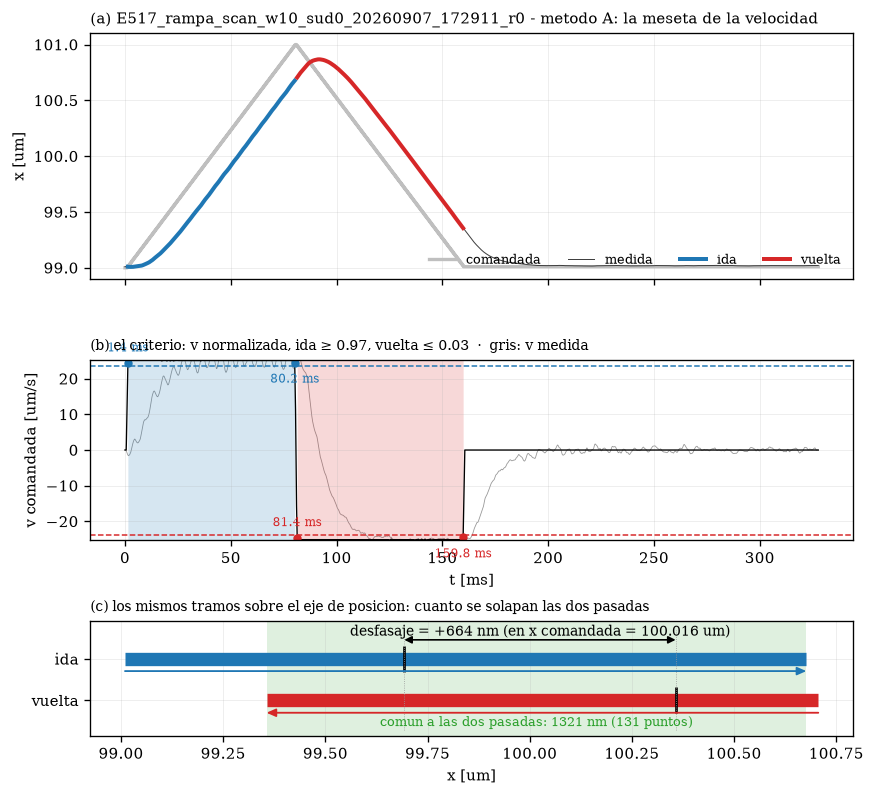

In [3]:
# =============================================================================
#  CELDA 2 - metodo A: el tramo lineal sale de la VELOCIDAD
# =============================================================================
CORRIDA = "E517_rampa_scan_w10_sud0_20260907_172911_r0"
FRAC = 0.97      # fraccion del recorrido min..max de la velocidad

r = cargar(CORRIDA)

# --- 1. ruido de sensado, con la platina quieta ------------------------------
ruido_r = ruido(r)

print(f"{CORRIDA}")
print(f"  amplitud {r['amplitud_um']} um · n_total {r['n_total']} · WTR {r['wtr']} · "
      f"RTR {r['rtr']} · SUD {r['sud']}")
print(f"  dx medido {r['dx_nm']:.2f} nm por punto · dwell {r['dwell_us']:.0f} us · "
      f"v = {r['v_um_s']:.2f} um/s\n")
print(f"zona quieta: {ruido_r['n']} muestras ({ruido_r['ms']:.0f} ms) con la platina parada, "
      f"al final de la grabacion")
print(f"  RMS de la posicion medida           {ruido_r['rms_nm']:6.3f} nm   "
      f"(incluye la deriva lenta)")
print(f"  error de sensado punto a punto      {ruido_r['sigma_nm']:6.3f} nm   "
      f"<- sigma de una muestra, de la diferencia entre puntos consecutivos")
print(f"  mediana |diferencias|               {ruido_r['mediana_dif_nm']:6.3f} nm   "
      f"<- saturada por la resolucion del recorder ({ruido_r['resolucion_nm']} nm)\n")

# --- 2. derivar las dos posiciones y aplicar el criterio ---------------------
n_pel = r["muestras_por_punto"]
v_cmd = derivar(r["t_ms"], r["x_cmd"], n_pel)
v_med = derivar(r["t_ms"], r["x_med"], n_pel)


def tramo_por_velocidad(r, frac=FRAC, cual_v="cmd"):
    """Metodo A: tramo lineal = meseta de la velocidad.

    Se normaliza v entre su minimo y su maximo dentro de la onda; la ida es
    donde la normalizada supera `frac` y la vuelta donde queda por debajo de
    1-frac. En un triangulo simetrico min = -v y max = +v, asi que el umbral
    cae en (2*frac-1) = 94 % de la meseta.
    """
    n = r["muestras_por_punto"]
    v = derivar(r["t_ms"], r["x_cmd"] if cual_v == "cmd" else r["x_med"], n)
    seg, umbrales = mesetas_en_patas(r, v, frac)
    return seg, v, umbrales


seg_A, v_cmd, umb = tramo_por_velocidad(r)
res_A = resumen(r, seg_A, f"METODO A · velocidad comandada · {FRAC:.0%} del recorrido")
print("En el panel (b) la velocidad MEDIDA va en gris: sirve para ver que el criterio\n"
      "no depende del suavizado. El control serio, con una senal medida, es la celda 3.")

fig = figura(r, seg_A, res_A, v_cmd, "v comandada [um/s]",
             umbrales=[(umb[0], COL["ida"]), (umb[1], COL["vuelta"])],
             titulo=f"(a) {CORRIDA} - metodo A: la meseta de la velocidad")
fig.axes[1].plot(r["t_ms"], v_med, color="0.6", lw=0.5, zorder=0)
fig.axes[1].set_title(f"(b) el criterio: v normalizada, ida ≥ {FRAC:.2f}, vuelta ≤ "
                      f"{1-FRAC:.2f}  ·  gris: v medida", fontsize=8.5, loc="left")
plt.show()

## Celda 3 — método B: el mismo cálculo, pero sobre el error que mide el controlador

El método A usa el comando, que es una cuenta nuestra. Éste usa una señal **medida e
independiente**: la columna `error_um` que devuelve el recorder del E-517.

En una rampa el lazo se atrasa una cantidad fija: `e = −v·tau`. Entonces el error sube
hasta una meseta durante la ida, cruza en el pico, y baja hasta la meseta opuesta durante
la vuelta. **Las dos mesetas son los dos tramos lineales**, y se las encuentra con
exactamente el mismo criterio de la celda 2 aplicado al error.

El umbral acá es más flojo (90 % en vez de 97 %) y a propósito: el error es señal medida
y trae encima el rizado de la escalera. Pedirle el 3 % sería pedirle menos que su propio
ruido y la máscara se partiría en tramitos de un milisegundo.

De yapa, la altura de la meseta da `tau = e/v` directamente.


┌─ METODO B · error del controlador · 90% de la meseta   ·   E517_rampa_scan_w10_sud0_20260907_172911_r0
│    ida  t =   15.28 ..   80.76 ms ( 65.48 ms)   v =   +24.737 um/s
│         tiempo perdido antes del tramo lineal :  14.12 ms
│         x medida    99.1066 ..  100.6903 um ( 1583.7 nm)   puntos utilizables:  163.8
│         lag medio  -314.4 nm
│ vuelta  t =  100.36 ..  159.96 ms ( 59.60 ms)   v =   -24.587 um/s
│         tiempo perdido antes del tramo lineal :  19.60 ms
│         x medida    99.3519 ..  100.7882 um ( 1436.3 nm)   puntos utilizables:  149.1
│         lag medio  +338.4 nm
│
│ puntos utilizables totales :  312.9 (ida + vuelta, en puntos de la wave de 10.05 nm)
│ solapamiento ida ∩ vuelta  : 99.3519 .. 100.6903 um  =   1338.4 nm (133 puntos)
│ desfasaje ida ↔ vuelta     :  +662.0 nm medido en x = 100.0211 um  (por la diferencia de lags: +652.8 nm)
│ se pierde de la    ida      :   245.3 nm = 15.5% del tramo, porque no encaja con la otra pasada
│ se pierde de la vuel

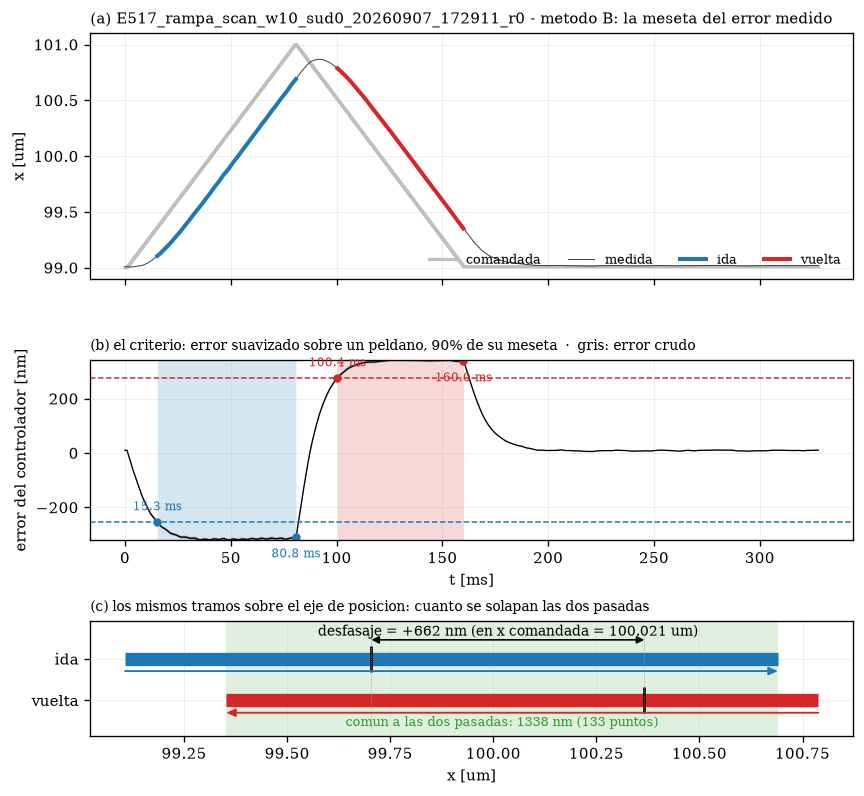

In [4]:
# =============================================================================
#  CELDA 3 - metodo B: el tramo lineal sale del ERROR QUE MIDE EL CONTROLADOR
# =============================================================================
# El metodo A usa el comando, que es una cuenta nuestra. Este usa una senal
# MEDIDA e independiente: la columna error_um del recorder del E-517.
# En una rampa el lazo se atrasa una cantidad fija, e = -v*tau: el error sube
# hasta una meseta en la ida, cruza en el pico, y baja hasta la meseta opuesta
# en la vuelta. Las dos mesetas son los dos tramos lineales.
FRAC_E = 0.90    # mas flojo que FRAC a proposito: el error es senal medida y
                 # trae encima el rizado de la escalera (unos pocos nm sobre un
                 # recorrido de cientos). Pedirle el 3 % es pedirle menos que
                 # su propio ruido y la mascara se parte en tramitos.


def tramo_por_error(r, frac=FRAC_E):
    """Metodo B: tramo lineal = meseta del error de seguimiento del controlador.

    Se suaviza el error sobre un peldano y se le aplica el mismo criterio de
    meseta que en la celda 2, cambiando el signo: en la ida el error es
    negativo (la platina va atras), en la vuelta positivo.
    """
    e = suavizar(r["err_nm"], r["muestras_por_punto"])
    seg, umbrales = mesetas_en_patas(r, -e, frac)
    return seg, e, umbrales


seg_B, e_s, umb_B = tramo_por_error(r)
res_B = resumen(r, seg_B, f"METODO B · error del controlador · {FRAC_E:.0%} de la meseta")

print("comparacion con el metodo A (bordes de cada tramo):")
for cual in ("ida", "vuelta"):
    a, b = res_A["tramos"].get(cual), res_B["tramos"].get(cual)
    if a and b:
        print(f"   {cual:>6}: A  {a['t0']:7.2f} .. {a['t1']:7.2f} ms   "
              f"B  {b['t0']:7.2f} .. {b['t1']:7.2f} ms   "
              f"diferencia {b['t0']-a['t0']:+.2f} / {b['t1']-a['t1']:+.2f} ms")
print(f"   desfasaje ida↔vuelta:  A {res_A['desfasaje_nm']:+.1f} nm   "
      f"B {res_B['desfasaje_nm']:+.1f} nm")
print(f"   2·v·tau con tau = e/v:  la meseta del error vale "
      f"{res_B['tramos']['ida']['lag_nm']:+.1f} nm en la ida y "
      f"{res_B['tramos']['vuelta']['lag_nm']:+.1f} nm en la vuelta "
      f"→ tau ≈ {abs(res_B['tramos']['ida']['lag_nm'])/1e3/abs(res_B['tramos']['ida']['v_um_s'])*1e3:.1f} ms")

# los umbrales estan definidos sobre -e, se dibujan sobre e con el signo dado
fig = figura(r, seg_B, res_B, e_s, "error del controlador [nm]",
             umbrales=[(-umb_B[0], COL["ida"]), (-umb_B[1], COL["vuelta"])],
             titulo=f"(a) {CORRIDA} - metodo B: la meseta del error medido")
fig.axes[1].plot(r["t_ms"], r["err_nm"], color="0.7", lw=0.4, zorder=0)
fig.axes[1].set_title(f"(b) el criterio: error suavizado sobre un peldano, "
                      f"{FRAC_E:.0%} de su meseta  ·  gris: error crudo",
                      fontsize=8.5, loc="left")
plt.show()

## Celda 4 — método C: hasta dónde una recta describe a la posición

Los dos métodos anteriores preguntan *"¿la velocidad (o el error) está en su meseta?"*.
Éste pregunta directamente lo que importa: **¿hasta dónde la posición es una recta en el
tiempo?**

Se ajusta una recta y se acepta el tramo mientras el residuo no supere un criterio. El
criterio **no se elige a mano**, sale del ruido de la propia medición:

- de la **mediana de las diferencias** entre puntos medidos consecutivos (la idea de
  partida) se obtiene una sigma robusta:
  `sigma = mediana(|Δx|) / (0.6745·√2)`
  — el 0.6745 convierte mediana en sigma para una gaussiana, y el √2 corrige que la
  diferencia de dos muestras independientes tiene √2 veces la sigma de una.
  **Con un detalle**: el recorder entrega la posición con 0.1 nm de resolución y con la
  platina quieta el ruido está por debajo, así que esa mediana da 0 ó 0.1 nm y satura.
  Por eso se toma la mayor entre ella y la desviación estándar de las mismas diferencias;
- pero hay un piso que el ruido no explica: la posición comandada es una **escalera** de
  `dx` nm. Aunque el seguimiento fuera perfecto, el residuo contra la recta oscilaría
  ±dx/2 **por construcción**.

Por eso el criterio adoptado es el **mayor de los dos**: `max(3·sigma, dx/2)`. Con un
criterio más chico que dx/2, el método no estaría midiendo la platina sino la
cuantización del generador.

El ajuste es iterativo y se siembra en la mitad central de la pata (que seguro está en la
parte recta): se ajusta, se mira el residuo de toda la pata, se acepta el tramo contiguo
más largo dentro del criterio, y se vuelve a ajustar hasta que deja de moverse.

Se hace sobre la posición **medida** (el resultado) y sobre la **comandada** (lo que hace
el generador, sin la platina). Al final, la tabla que compara los tres métodos.


criterio de residuo: max(K·sigma, dx/2) con K = 3.0
   sigma de sensado                            :  0.038 nm  → K·sigma = 0.11 nm
   media escalera dx/2                         :  5.025 nm
   criterio adoptado                           :  5.025 nm

┌─ METODO C · recta sobre la posicion MEDIDA · |res| ≤ 5.0 nm   ·   E517_rampa_scan_w10_sud0_20260907_172911_r0
│    ida  t =   30.24 ..   80.76 ms ( 50.52 ms)   v =   +25.182 um/s
│         tiempo perdido antes del tramo lineal :  29.08 ms
│         x medida    99.4238 ..  100.6903 um ( 1266.5 nm)   puntos utilizables:  126.4
│         lag medio  -315.9 nm
│ vuelta  t =  118.16 ..  159.96 ms ( 41.80 ms)   v =   -25.137 um/s
│         tiempo perdido antes del tramo lineal :  37.40 ms
│         x medida    99.3519 ..  100.4003 um ( 1048.4 nm)   puntos utilizables:  104.6
│         lag medio  +340.3 nm
│
│ puntos utilizables totales :  231.0 (ida + vuelta, en puntos de la wave de 10.05 nm)
│ solapamiento ida ∩ vuelta  : 99.4238 .. 100.4003 u

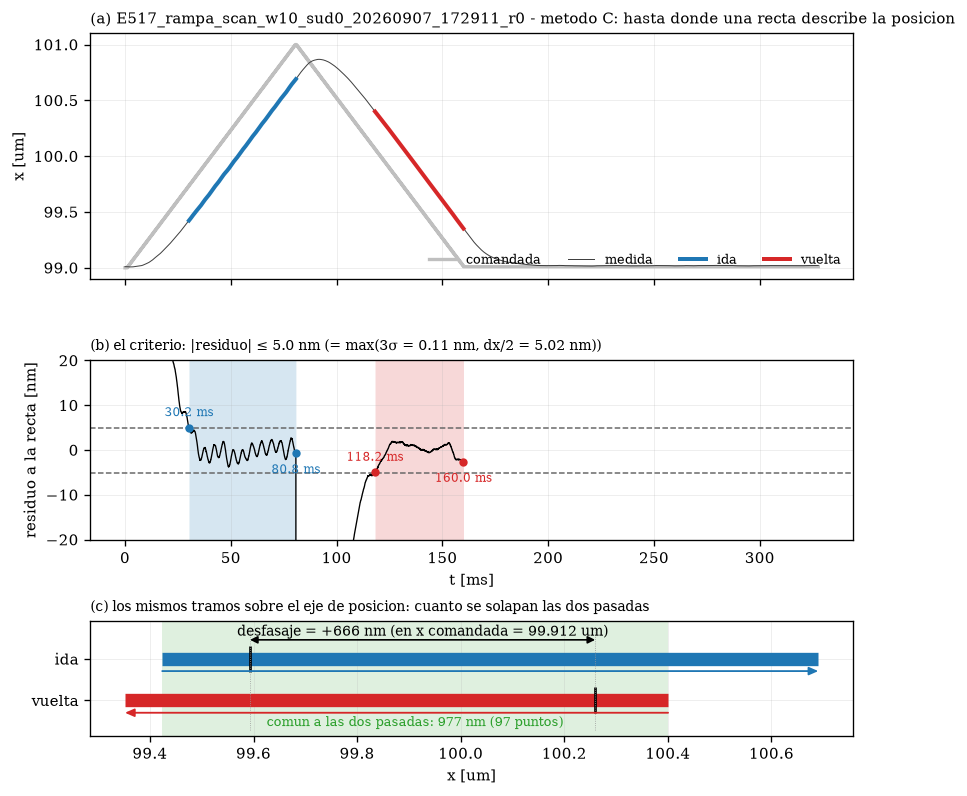

In [5]:
# =============================================================================
#  CELDA 4 - metodo C: el tramo lineal es donde una RECTA todavia describe
#            a los datos
# =============================================================================
# Los metodos A y B preguntan "¿la velocidad (o el error) esta en su meseta?".
# Este pregunta directamente lo que a nosotros nos importa: ¿hasta donde la
# posicion es una recta en el tiempo? Se ajusta una recta y se acepta el tramo
# mientras el residuo no supere un criterio.
#
# El criterio no se elige a mano: sale del ruido de la propia medicion. La
# estimacion robusta a partir de la mediana de las diferencias entre puntos
# medidos consecutivos es
#       sigma = mediana(|dx|) / (0.6745 * sqrt(2))
# (la mediana de |dx| es el 0.6745 de la sigma de la diferencia, y la
# diferencia de dos muestras independientes tiene sqrt(2) veces la sigma de
# una). A eso se le suma que la posicion comandada es una ESCALERA: aunque el
# seguimiento fuera perfecto, el residuo contra la recta oscilaria +-dx/2 por
# construccion. Por eso el criterio es el mayor de los dos.
K = 3.0          # cuantas sigmas se toleran


def criterio_residuo(r, k=K):
    """Cuanto residuo se tolera, en nm, y de donde sale."""
    n = ruido(r)
    # la estimacion robusta pedida (mediana de |diferencias|) y la de siempre
    # (desviacion estandar de esas diferencias). Con la platina quieta la
    # mediana satura en la resolucion del recorder, asi que se toma la mayor.
    sigma = max(n["mediana_dif_nm"] / (0.6745 * np.sqrt(2)), n["sigma_nm"])
    escalera = r["dx_nm"] / 2
    return max(k * sigma, escalera), sigma, escalera


def tramo_por_recta(r, x, i0, i1, criterio_nm, n_iter=8):
    """Tramo contiguo mas largo donde una recta ajusta dentro del criterio.

    Semilla: la mitad central de la pata (que seguro esta en la parte recta).
    Se ajusta, se miran los residuos de toda la pata, se acepta el tramo
    contiguo mas largo con |residuo| <= criterio, y se vuelve a ajustar sobre
    ese tramo hasta que deja de moverse.
    """
    t = r["t_ms"]
    idx = np.arange(i0, i1 + 1)
    sel = idx[len(idx) // 4: 3 * len(idx) // 4]
    p, res = np.polyfit(t[sel], x[sel], 1), None
    for _ in range(n_iter):
        p = np.polyfit(t[sel], x[sel], 1)
        res = (x[idx] - np.polyval(p, t[idx])) * 1e3
        nuevo = idx[tramo_mas_largo(np.abs(res) <= criterio_nm)]
        if len(nuevo) < 3 or np.array_equal(nuevo, sel):
            break
        sel = nuevo
    return sel, p, idx, res


def tramos_por_recta(r, x, k=K):
    """Metodo C sobre las dos patas. Devuelve la segmentacion y el residuo."""
    crit, sigma, escalera = criterio_residuo(r, k)
    seg, residuo = {}, np.full(len(r["t_ms"]), np.nan)
    for cual, (i0, i1) in (("ida", (r["arranque"], r["pico"])),
                           ("vuelta", (r["pico"] + 1, r["fin"]))):
        sel, p, idx, res = tramo_por_recta(r, x, i0, i1, crit)
        seg[cual] = sel
        residuo[idx] = res
    return seg, residuo, crit, sigma, escalera


crit, sigma, escalera = criterio_residuo(r)
print(f"criterio de residuo: max(K·sigma, dx/2) con K = {K}")
print(f"   sigma de sensado                            : {sigma:6.3f} nm  "
      f"→ K·sigma = {K*sigma:.2f} nm")
print(f"   media escalera dx/2                         : {escalera:6.3f} nm")
print(f"   criterio adoptado                           : {crit:6.3f} nm\n")

seg_C, residuo_C, *_ = tramos_por_recta(r, r["x_med"])
seg_Cc, residuo_Cc, *_ = tramos_por_recta(r, r["x_cmd"])
res_C = resumen(r, seg_C, f"METODO C · recta sobre la posicion MEDIDA · |res| ≤ {crit:.1f} nm")
res_Cc = resumen(r, seg_Cc, "METODO C · recta sobre la posicion COMANDADA", imprimir=False)

print("la misma recta sobre la posicion comandada (lo que hace el generador, "
      "sin la platina):")
for cual in ("ida", "vuelta"):
    a, b = res_C["tramos"].get(cual), res_Cc["tramos"].get(cual)
    if a and b:
        print(f"   {cual:>6}: medida {a['t0']:7.2f} .. {a['t1']:7.2f} ms   "
              f"comandada {b['t0']:7.2f} .. {b['t1']:7.2f} ms")

print("\ncomparacion de los tres metodos (tiempo perdido antes del tramo lineal "
      "y puntos utiles):")
print(f"   {'metodo':<10}{'t antes ida':>13}{'t antes vuelta':>16}"
      f"{'puntos utiles':>15}{'solapamiento':>14}{'desfasaje':>12}")
for nombre, rr in (("A · v", res_A), ("B · error", res_B), ("C · recta", res_C)):
    print(f"   {nombre:<10}{rr['tramos']['ida']['t_antes_ms']:>11.2f} ms"
          f"{rr['tramos']['vuelta']['t_antes_ms']:>14.2f} ms"
          f"{rr['puntos_totales']:>15.1f}"
          f"{rr['solapamiento_nm']:>11.0f} nm{rr['desfasaje_nm']:>+10.0f} nm")

fig = figura(r, seg_C, res_C, residuo_C, "residuo a la recta [nm]",
             umbrales=[(crit, "0.4"), (-crit, "0.4")],
             titulo=f"(a) {CORRIDA} - metodo C: hasta donde una recta describe la posicion",
             ylim_senal=(-4 * crit, 4 * crit))
fig.axes[1].set_title(f"(b) el criterio: |residuo| ≤ {crit:.1f} nm "
                      f"(= max(3σ = {K*sigma:.2f} nm, dx/2 = {escalera:.2f} nm))",
                      fontsize=8.5, loc="left")
plt.show()

## Celda 5 — barrido en WTR: misma amplitud, mismos puntos, distinta velocidad

Se vuelve a filtrar la lista de la celda 1 buscando corridas que **compartan amplitud y
n_total** y sólo difieran en **WTR**, con el mismo SUD (se prefiere SUD = 0; si no hay
suficientes, se usa el grupo con más valores de WTR aunque el SUD no sea cero — la celda
imprime los candidatos antes de elegir).

Con amplitud y n_total fijos, `dx` (el tamaño del pixel, o sea la **precisión espacial**)
no cambia: lo único que cambia es el tiempo que se le da a cada pixel. Entonces WTR es,
literalmente, la perilla de la velocidad.

Lo que se mide en cada una:

- `v`, que baja como 1/WTR;
- el **desfasaje** ida↔vuelta, que tiene que crecer lineal con v (es `2·v·tau`): el panel
  (b) lo contrasta con esa predicción;
- qué fracción de la pasada es lineal y cuántos de esos puntos son **comunes** a las dos pasadas;
- el residuo rms a la recta (celda 4) y el **rendimiento**: puntos útiles por ms de wave.

El compromiso está en el panel (d): ir rápido rinde más puntos por segundo, pero paga
desfasaje y residuo.


familias candidatas (se prefiere sud = 0):


,amplitud_um,n_total,sud,n
5,1.0,400,0,3
9,1.0,400,80,5
8,1.0,400,40,3
7,1.0,400,20,2



familia elegida: amplitud 1.0 um · n_total 400 · SUD 0 · 3 valores de WTR: [10, 20, 40]



,wtr,v_um_s,dx_nm,t_antes_A_ms,dur_ida_A_ms,frac_lineal_A,puntos_A,comunes_A,desf_A_nm,residuo_rms_nm,rendimiento_pts_ms
0,10,25.125,10.05,0.20,78.84,0.990,393.4,131.423,663.8,1.841,0.821
1,20,12.563,10.05,0.36,157.72,0.991,393.4,163.692,344.9,1.440,0.512
2,40,6.281,10.05,0.80,315.36,0.990,393.4,180.100,173.7,1.522,0.281


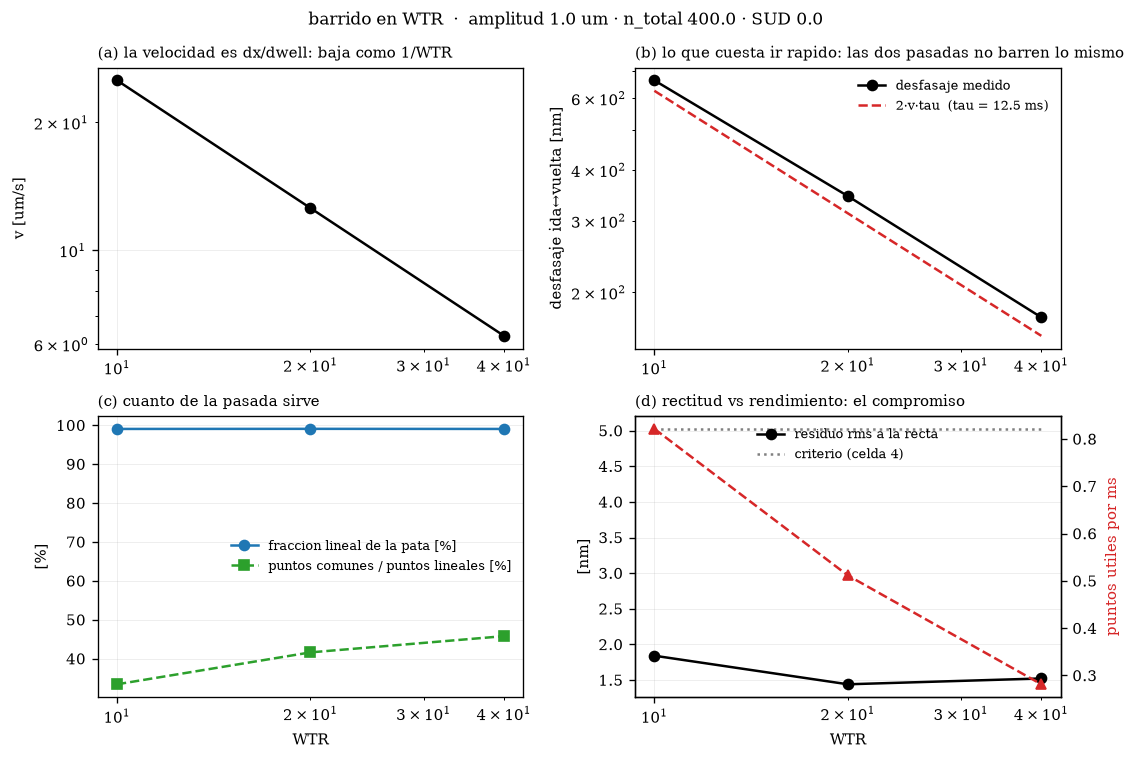


mayor rendimiento: WTR = 10 → v = 25.1 um/s, 131 puntos comunes en 160 ms de wave, desfasaje 664 nm
El desfasaje crece lineal con v: es 2·v·tau. Si el scan tiene que cerrar ida y vuelta en la misma grilla,
el WTR lo fija esa tolerancia, no el rendimiento.


In [6]:
# =============================================================================
#  CELDA 5 - barrido en WTR: misma amplitud, mismos puntos, distinta velocidad
# =============================================================================
# WTR = cuantos ciclos de servo (40 us) dura cada punto de la wave. Con la
# amplitud y n_total fijos, dx (el tamano del pixel) no cambia: lo unico que
# cambia es el tiempo que se le da a cada pixel, o sea la velocidad.
# Se busca la familia de corridas que comparte amplitud y n_total y solo
# difiere en WTR, con el mismo SUD (preferentemente 0).

def metricas(stem, frac=FRAC, frac_e=FRAC_E, k=K):
    """Una fila por corrida, con los tres metodos aplicados."""
    r = cargar(stem)
    fila = {"stem": stem, "wtr": r["wtr"], "rtr": r["rtr"], "sud": r["sud"],
            "n_total": r["n_total"], "amplitud_um": r["amplitud_um"],
            "dwell_us": r["dwell_us"], "dx_nm": r["dx_nm"], "v_um_s": r["v_um_s"],
            "wave_ms": r["n_total"] * r["dwell_us"] / 1e3,
            "pata_ms": r["t_ms"][r["pico"]] - r["t_ms"][r["arranque"]]}

    seg_a, _, _ = tramo_por_velocidad(r, frac)
    ra = resumen(r, seg_a, imprimir=False)
    seg_b, _, _ = tramo_por_error(r, frac_e)
    rb = resumen(r, seg_b, imprimir=False)
    seg_c, residuo, crit, sigma, escalera = tramos_por_recta(r, r["x_med"], k)
    rc = resumen(r, seg_c, imprimir=False)
    _, residuo_cmd, *_ = tramos_por_recta(r, r["x_cmd"], k)

    for etiqueta, rr in (("A", ra), ("B", rb), ("C", rc)):
        d = rr["tramos"].get("ida", {})
        fila[f"t_antes_{etiqueta}_ms"] = d.get("t_antes_ms", np.nan)
        fila[f"dur_ida_{etiqueta}_ms"] = d.get("dur_ms", np.nan)
        fila[f"largo_ida_{etiqueta}_nm"] = d.get("largo_nm", np.nan)
        fila[f"puntos_{etiqueta}"] = rr.get("puntos_totales", np.nan)
        fila[f"solap_{etiqueta}_nm"] = rr.get("solapamiento_nm", np.nan)
        fila[f"desf_{etiqueta}_nm"] = rr.get("desfasaje_nm", np.nan)
        fila[f"comunes_{etiqueta}"] = rr.get("puntos_comunes", np.nan)
        fila[f"inversion_{etiqueta}_ms"] = rr.get("t_inversion_ms", np.nan)
    fila["frac_lineal_A"] = fila["dur_ida_A_ms"] / fila["pata_ms"]
    fila["lag_ida_nm"] = ra["tramos"].get("ida", {}).get("lag_nm", np.nan)
    fila["criterio_nm"] = crit
    fila["sigma_nm"] = sigma
    i = rc["tramos"].get("ida", {}).get("i", np.array([], int))
    fila["residuo_rms_nm"] = float(np.sqrt(np.nanmean(residuo[i] ** 2))) if len(i) else np.nan
    fila["residuo_cmd_pp_nm"] = (float(np.nanpercentile(residuo_cmd[i], 97.5)
                                       - np.nanpercentile(residuo_cmd[i], 2.5))
                                 if len(i) else np.nan)
    # rendimiento: cuantos puntos utiles (los comunes a ida y vuelta) por ms de wave
    fila["rendimiento_pts_ms"] = fila["comunes_A"] / fila["wave_ms"]
    return fila


def elegir_familia(tabla, fija, varia, sud_preferido=0, minimo=2):
    """Grupos que comparten `fija` y barren `varia`. Se prefiere sud = 0."""
    g = (tabla.groupby(fija)[varia].nunique().reset_index(name="n")
         .query("n >= @minimo"))
    if g.empty:
        raise RuntimeError("no hay familia con suficientes valores")
    if "sud" in fija and (g.sud == sud_preferido).any():
        pref = g[g.sud == sud_preferido].sort_values("n", ascending=False)
        otras = g[g.sud != sud_preferido].sort_values("n", ascending=False)
        print("familias candidatas (se prefiere sud = 0):")
        display(pd.concat([pref, otras]))
        return pref.iloc[0]
    g = g.sort_values("n", ascending=False)
    print("familias candidatas:")
    display(g)
    return g.iloc[0]


fam_wtr = elegir_familia(RAMPAS, ["amplitud_um", "n_total", "sud"], "wtr")
sel = RAMPAS.query("amplitud_um == @fam_wtr.amplitud_um and n_total == @fam_wtr.n_total "
                   "and sud == @fam_wtr.sud").drop_duplicates("wtr").sort_values("wtr")
print(f"\nfamilia elegida: amplitud {fam_wtr.amplitud_um} um · n_total "
      f"{int(fam_wtr.n_total)} · SUD {int(fam_wtr.sud)} · {len(sel)} valores de WTR: "
      f"{list(sel.wtr)}\n")

M_WTR = pd.DataFrame([metricas(s) for s in sel.stem])
display(M_WTR[["wtr", "v_um_s", "dx_nm", "t_antes_A_ms", "dur_ida_A_ms", "frac_lineal_A",
               "puntos_A", "comunes_A", "desf_A_nm", "residuo_rms_nm",
               "rendimiento_pts_ms"]].round(3))

fig, ax = plt.subplots(2, 2, figsize=(9.5, 6.4))
ax = ax.ravel()
ax[0].loglog(M_WTR.wtr, M_WTR.v_um_s, "o-", color="k")
ax[0].set_ylabel("v [um/s]")
ax[0].set_title("(a) la velocidad es dx/dwell: baja como 1/WTR", fontsize=9, loc="left")

ax[1].plot(M_WTR.wtr, M_WTR.desf_A_nm.abs(), "o-", color="k", label="desfasaje medido")
tau_ms = np.nanmedian(np.abs(M_WTR.lag_ida_nm) / (M_WTR.v_um_s * 1e3) * 1e3)
ax[1].plot(M_WTR.wtr, 2 * M_WTR.v_um_s * tau_ms * 1e-3 * 1e3, "--", color=COL["vuelta"],
           label=f"2·v·tau  (tau = {tau_ms:.1f} ms)")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_ylabel("desfasaje ida↔vuelta [nm]")
ax[1].legend(frameon=False, fontsize=8)
ax[1].set_title("(b) lo que cuesta ir rapido: las dos pasadas no barren lo mismo",
                fontsize=9, loc="left")

ax[2].plot(M_WTR.wtr, M_WTR.frac_lineal_A * 100, "o-", color=COL["ida"],
           label="fraccion lineal de la pata [%]")
ax[2].plot(M_WTR.wtr, M_WTR.comunes_A / M_WTR.puntos_A * 100, "s--", color=COL["comun"],
           label="puntos comunes / puntos lineales [%]")
ax[2].set_xscale("log")
ax[2].set_ylabel("[%]")
ax[2].set_xlabel("WTR")
ax[2].legend(frameon=False, fontsize=8)
ax[2].set_title("(c) cuanto de la pasada sirve", fontsize=9, loc="left")

ax[3].plot(M_WTR.wtr, M_WTR.residuo_rms_nm, "o-", color="k", label="residuo rms a la recta")
ax[3].plot(M_WTR.wtr, M_WTR.criterio_nm, ":", color="0.5", label="criterio (celda 4)")
ax[3].set_xscale("log")
ax[3].set_ylabel("[nm]")
ax[3].set_xlabel("WTR")
axb = ax[3].twinx()
axb.plot(M_WTR.wtr, M_WTR.rendimiento_pts_ms, "^--", color=COL["vuelta"])
axb.set_ylabel("puntos utiles por ms", color=COL["vuelta"])
axb.grid(False)
ax[3].legend(frameon=False, fontsize=8, loc="upper center")
ax[3].set_title("(d) rectitud vs rendimiento: el compromiso", fontsize=9, loc="left")
fig.suptitle(f"barrido en WTR  ·  amplitud {fam_wtr.amplitud_um} um · n_total "
             f"{fam_wtr.n_total} · SUD {fam_wtr.sud}", fontsize=10)
plt.tight_layout()
plt.show()

mejor = M_WTR.loc[M_WTR.rendimiento_pts_ms.idxmax()]
print(f"\nmayor rendimiento: WTR = {mejor.wtr:.0f} → v = {mejor.v_um_s:.1f} um/s, "
      f"{mejor.comunes_A:.0f} puntos comunes en {mejor.wave_ms:.0f} ms de wave, "
      f"desfasaje {abs(mejor.desf_A_nm):.0f} nm")
print("El desfasaje crece lineal con v: es 2·v·tau. Si el scan tiene que cerrar "
      "ida y vuelta en la misma grilla,\nel WTR lo fija esa tolerancia, no el "
      "rendimiento.")

## Celda 6 — barrido en SUD, con WTR y todo lo demás fijo

SUD son los puntos que el generador gasta en cada punta acelerando y frenando: se pagan
en tiempo y no se usan para medir. Las dos preguntas:

- ¿bajan el **tiempo de inversión** (frenar la ida + arrancar la vuelta)?
- ¿**alargan** el tramo lineal, o sólo lo corren?

Ojo con una trampa: con SUD > 0 el generador reparte los `n_total` puntos de forma **no
uniforme** — gasta puntos en las puntas y los del medio quedan más separados. Entonces
`dx` y `v` suben aunque no se haya tocado WTR. Por eso la tabla hay que leerla con las
dos columnas juntas: `dx_nm` es la precisión espacial y `comunes_A` cuántos puntos útiles
sobreviven.

**Juntando las celdas 5 y 6:** WTR fija la velocidad (y con ella el desfasaje, que es el
que limita si se quiere usar ida y vuelta sobre la misma grilla); SUD fija cuántos puntos
hay que poner adelante y atrás para que el tramo del medio sea estable. La precisión
espacial es `dx = 2·amplitud/n_total` (corregida por el reparto que hace SUD), y la
velocidad de scan es `v = dx/dwell`.


familias candidatas:


,amplitud_um,n_total,wtr,n
4,1.0,400,10,4
5,1.0,400,20,4
6,1.0,400,40,4



familia elegida: amplitud 1.0 um · n_total 400 · WTR 10 · SUD: [0, 20, 40, 80]



,sud,v_um_s,dx_nm,t_antes_A_ms,dur_ida_A_ms,frac_lineal_A,largo_ida_A_nm,puntos_A,comunes_A,inversion_A_ms,desf_A_nm,residuo_rms_nm
0,0,25.125,10.05,0.20,78.84,0.990,1667.1,393.4,131.423,1.16,663.8,1.841
1,20,28.000,11.20,5.08,65.84,0.848,1561.4,329.4,99.964,14.20,735.9,1.762
2,40,31.500,12.60,11.24,52.08,0.678,1402.2,260.6,65.579,27.80,820.3,2.273
3,80,42.750,17.10,24.32,23.40,0.310,805.8,117.2,0.000,56.60,1025.7,3.445


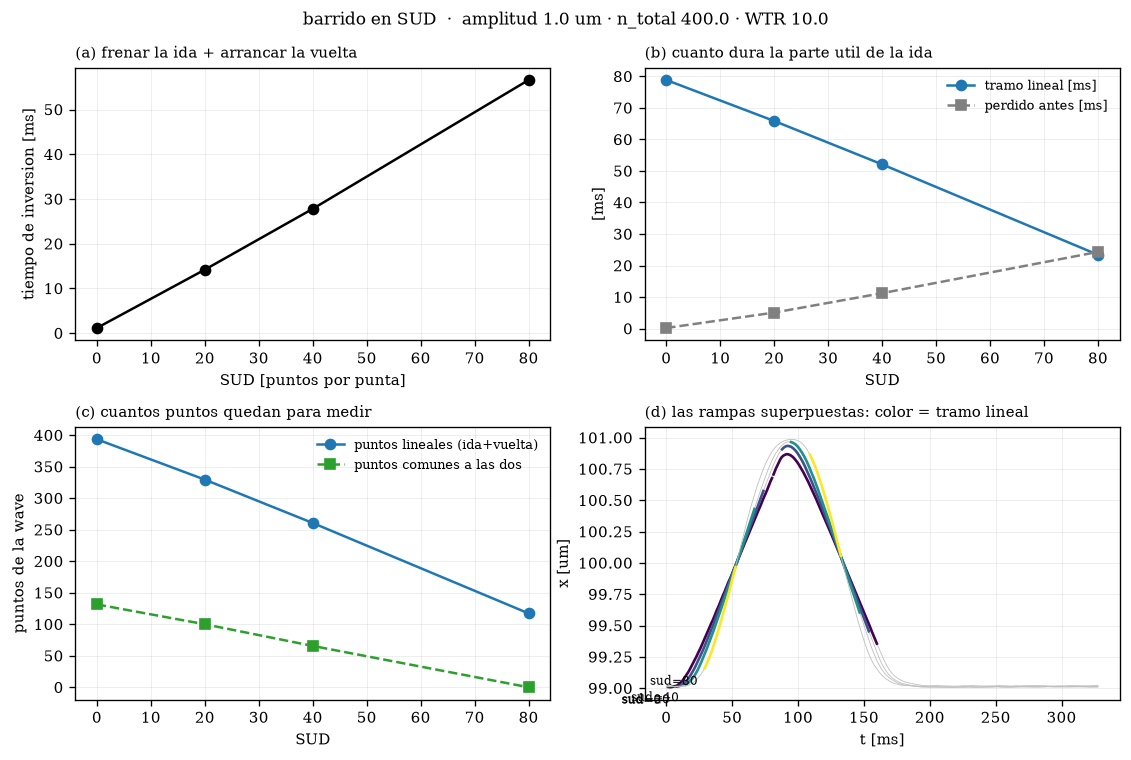


mas puntos comunes: SUD = 0 (131 puntos, tramo lineal de 78.8 ms, inversion de 1.2 ms)
menor tiempo de inversion: SUD = 0

Con SUD > 0 el generador reparte los puntos de forma no uniforme: gasta
puntos en las puntas y los del medio quedan mas separados, asi que dx (y v)
suben. Por eso hay que mirar las dos columnas juntas: dx_nm dice la
precision espacial y comunes_A cuantos puntos utiles sobreviven.


In [7]:
# =============================================================================
#  CELDA 6 - barrido en SUD con todo lo demas fijo
# =============================================================================
# SUD (speedupdown) = cuantos puntos de cada punta gasta el generador en
# acelerar y frenar. Son puntos que se pagan en tiempo y no se usan para medir.
# La pregunta es doble:
#   - ¿bajan el tiempo de inversion (frenar la ida + arrancar la vuelta)?
#   - ¿alargan el tramo lineal, o solo lo corren?

fam_sud = elegir_familia(RAMPAS, ["amplitud_um", "n_total", "wtr"], "sud",
                         sud_preferido=None, minimo=3)
sel_s = RAMPAS.query("amplitud_um == @fam_sud.amplitud_um and n_total == @fam_sud.n_total "
                     "and wtr == @fam_sud.wtr").drop_duplicates("sud").sort_values("sud")
print(f"\nfamilia elegida: amplitud {fam_sud.amplitud_um} um · n_total "
      f"{int(fam_sud.n_total)} · WTR {int(fam_sud.wtr)} · SUD: {list(sel_s.sud)}\n")

M_SUD = pd.DataFrame([metricas(s) for s in sel_s.stem])
M_SUD["puntos_punta"] = M_SUD.sud
display(M_SUD[["sud", "v_um_s", "dx_nm", "t_antes_A_ms", "dur_ida_A_ms", "frac_lineal_A",
               "largo_ida_A_nm", "puntos_A", "comunes_A", "inversion_A_ms",
               "desf_A_nm", "residuo_rms_nm"]].round(3))

fig, ax = plt.subplots(2, 2, figsize=(9.5, 6.4))
ax = ax.ravel()
ax[0].plot(M_SUD.sud, M_SUD.inversion_A_ms, "o-", color="k")
ax[0].set_ylabel("tiempo de inversion [ms]")
ax[0].set_xlabel("SUD [puntos por punta]")
ax[0].set_title("(a) frenar la ida + arrancar la vuelta", fontsize=9, loc="left")

ax[1].plot(M_SUD.sud, M_SUD.dur_ida_A_ms, "o-", color=COL["ida"], label="tramo lineal [ms]")
ax[1].plot(M_SUD.sud, M_SUD.t_antes_A_ms, "s--", color="0.5", label="perdido antes [ms]")
ax[1].set_ylabel("[ms]")
ax[1].set_xlabel("SUD")
ax[1].legend(frameon=False, fontsize=8)
ax[1].set_title("(b) cuanto dura la parte util de la ida", fontsize=9, loc="left")

ax[2].plot(M_SUD.sud, M_SUD.puntos_A, "o-", color=COL["ida"], label="puntos lineales (ida+vuelta)")
ax[2].plot(M_SUD.sud, M_SUD.comunes_A, "s--", color=COL["comun"], label="puntos comunes a las dos")
ax[2].set_ylabel("puntos de la wave")
ax[2].set_xlabel("SUD")
ax[2].legend(frameon=False, fontsize=8)
ax[2].set_title("(c) cuantos puntos quedan para medir", fontsize=9, loc="left")

for _, f in M_SUD.iterrows():
    rr = cargar(f.stem)
    sg, _, _ = tramo_por_velocidad(rr, FRAC)
    ax[3].plot(rr["t_ms"], rr["x_med"], lw=0.5, color="0.75")
    for cual in ("ida", "vuelta"):
        i = sg[cual]
        if len(i):
            ax[3].plot(rr["t_ms"][i], rr["x_med"][i], lw=1.6,
                       color=plt.cm.viridis(f.sud / max(M_SUD.sud.max(), 1)))
    ax[3].annotate(f"sud={f.sud:.0f}", (rr["t_ms"][sg['ida'][0]], rr["x_med"][sg['ida'][0]]),
                   fontsize=7, textcoords="offset points", xytext=(-4, -10), ha="right")
ax[3].set_ylabel("x [um]")
ax[3].set_xlabel("t [ms]")
ax[3].set_title("(d) las rampas superpuestas: color = tramo lineal", fontsize=9, loc="left")
fig.suptitle(f"barrido en SUD  ·  amplitud {fam_sud.amplitud_um} um · n_total "
             f"{fam_sud.n_total} · WTR {fam_sud.wtr}", fontsize=10)
plt.tight_layout()
plt.show()

mejor_s = M_SUD.loc[M_SUD.comunes_A.idxmax()]
print(f"\nmas puntos comunes: SUD = {mejor_s.sud:.0f} "
      f"({mejor_s.comunes_A:.0f} puntos, tramo lineal de {mejor_s.dur_ida_A_ms:.1f} ms, "
      f"inversion de {mejor_s.inversion_A_ms:.1f} ms)")
print(f"menor tiempo de inversion: SUD = {M_SUD.loc[M_SUD.inversion_A_ms.idxmin()].sud:.0f}")
print("\nCon SUD > 0 el generador reparte los puntos de forma no uniforme: gasta\n"
      "puntos en las puntas y los del medio quedan mas separados, asi que dx (y v)\n"
      "suben. Por eso hay que mirar las dos columnas juntas: dx_nm dice la\n"
      "precision espacial y comunes_A cuantos puntos utiles sobreviven.")

## Celda 7 — la oscilación que queda: residuos a la recta para distintos WTR y SUD

Ésta era la celda dudosa. **Propongo conservarla, pero con un cambio**: mirar el residuo
de la comandada y el de la medida *juntos*, porque separados no se pueden interpretar.

El residuo de la **comandada** no es un defecto de la platina: es la escalera. Un diente
de sierra de amplitud `dx` pico a pico, que no depende de WTR. Es el **piso geométrico**:
dice cuánta ondulación hay sí o sí.

El residuo de la **medida** es ese mismo diente de sierra, filtrado por la platina (que no
llega a seguir cada peldaño), más la oscilación propia del lazo. Entonces la lectura es
directa:

- medido **por debajo** del comandado → la platina está **alisando** la escalera (bien: el
  movimiento real es más suave que el comando);
- medido **por encima** → la platina está **agregando** movimiento propio, y ahí sí hay un
  problema de estabilidad.

Los paneles de arriba muestran las trazas del residuo dentro del tramo lineal; los de
abajo, la amplitud pico a pico contra WTR y contra SUD, con `dx` dibujado de referencia.

> Si al final se quiere recortar el cuaderno, ésta es la celda a sacar: no agrega un
> criterio nuevo, sino la lectura fina del criterio de la celda 4.



barrido en WTR:


,wtr,dx_nm,pp_med_nm,pp_cmd_nm,rms_med_nm,rms_cmd_nm
0,10,10.05,7.24,9.10,1.84,2.89
1,20,10.05,5.99,9.55,1.44,2.90
2,40,10.05,6.11,9.10,1.52,2.89



barrido en SUD:


,sud,dx_nm,pp_med_nm,pp_cmd_nm,rms_med_nm,rms_cmd_nm
0,0,10.05,7.24,9.10,1.84,2.89
1,20,11.20,5.90,80.55,1.76,19.06
2,40,12.60,8.43,11.41,2.27,3.63
3,80,17.10,12.11,237.75,3.44,540.42


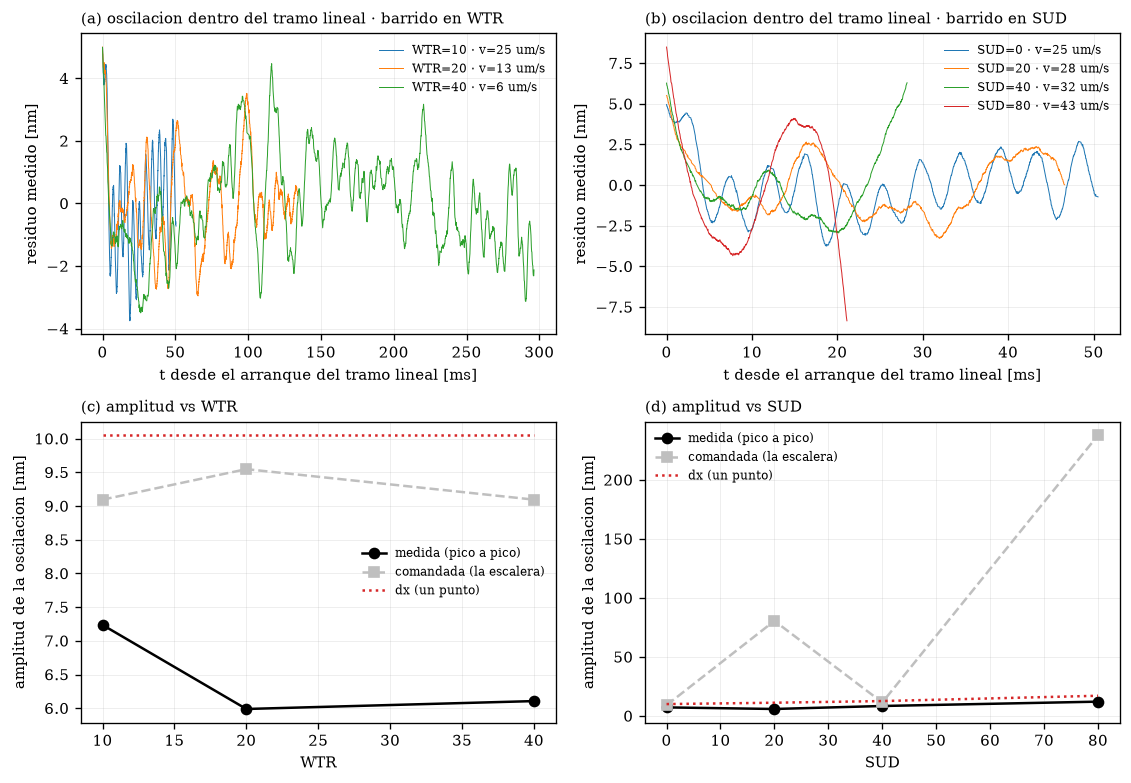

In [8]:
# =============================================================================
#  CELDA 7 - la oscilacion que queda: residuos a la recta para cada WTR y SUD
# =============================================================================
# En el tramo lineal la posicion no es una recta perfecta. Hay dos cosas
# distintas encima, y el residuo permite separarlas:
#   - la COMANDADA no puede ser recta: es una escalera de dx nm. Su residuo es
#     un diente de sierra de amplitud dx (pico a pico), y no depende de WTR.
#     Es un piso geometrico: fija cuanta ondulacion hay si o si.
#   - la MEDIDA ademas filtra esa escalera (la platina no llega a seguir cada
#     peldano) y le suma su propia oscilacion. Si su residuo es MENOR que el
#     de la comandada, la platina esta alisando la escalera; si es mayor, esta
#     agregando movimiento propio.

def residuos_ida(stem, k=K):
    """Residuo a la recta en el tramo lineal de la ida, medido y comandado."""
    r = cargar(stem)
    seg, res_med, crit, sigma, escalera = tramos_por_recta(r, r["x_med"], k)
    _, res_cmd, *_ = tramos_por_recta(r, r["x_cmd"], k)
    i = seg["ida"]
    pp = lambda y: float(np.nanpercentile(y[i], 97.5) - np.nanpercentile(y[i], 2.5))
    rms = lambda y: float(np.sqrt(np.nanmean(y[i] ** 2)))
    return {"stem": stem, "wtr": r["wtr"], "sud": r["sud"], "dx_nm": r["dx_nm"],
            "v_um_s": r["v_um_s"], "i": i, "t_ms": r["t_ms"],
            "res_med": res_med, "res_cmd": res_cmd,
            "pp_med_nm": pp(res_med), "pp_cmd_nm": pp(res_cmd),
            "rms_med_nm": rms(res_med), "rms_cmd_nm": rms(res_cmd)}


R_WTR = [residuos_ida(s) for s in sel.stem]
R_SUD = [residuos_ida(s) for s in sel_s.stem]

fig, ax = plt.subplots(2, 2, figsize=(9.5, 6.6))
for col, (lista, clave, etiqueta) in enumerate(
        ((R_WTR, "wtr", "WTR"), (R_SUD, "sud", "SUD"))):
    for d in lista:
        i = d["i"]
        t0 = d["t_ms"][i] - d["t_ms"][i[0]]
        ax[0][col].plot(t0, d["res_med"][i], lw=0.6,
                        label=f"{etiqueta}={d[clave]} · v={d['v_um_s']:.0f} um/s")
    ax[0][col].set_ylabel("residuo medido [nm]")
    ax[0][col].set_xlabel("t desde el arranque del tramo lineal [ms]")
    ax[0][col].legend(frameon=False, fontsize=7)
    ax[0][col].set_title(f"({'ab'[col]}) oscilacion dentro del tramo lineal · "
                         f"barrido en {etiqueta}", fontsize=9, loc="left")

    tab = pd.DataFrame([{k: d[k] for k in (clave, "dx_nm", "pp_med_nm", "pp_cmd_nm",
                                           "rms_med_nm", "rms_cmd_nm")} for d in lista])
    tab = tab.sort_values(clave)
    ax[1][col].plot(tab[clave], tab.pp_med_nm, "o-", color="k", label="medida (pico a pico)")
    ax[1][col].plot(tab[clave], tab.pp_cmd_nm, "s--", color=COL["cmd"],
                    label="comandada (la escalera)")
    ax[1][col].plot(tab[clave], tab.dx_nm, ":", color=COL["vuelta"], label="dx (un punto)")
    ax[1][col].set_xlabel(etiqueta)
    ax[1][col].set_ylabel("amplitud de la oscilacion [nm]")
    ax[1][col].legend(frameon=False, fontsize=7)
    ax[1][col].set_title(f"({'cd'[col]}) amplitud vs {etiqueta}", fontsize=9, loc="left")
    print(f"\nbarrido en {etiqueta}:")
    display(tab.round(2))
plt.tight_layout()
plt.show()